In [36]:
# function to solve B using non-negative least squares
from scipy.optimize import nnls
%cd ..
from compiler_options import compiler_decorator
from myutils import khatri_rao_power, khatri_rao_product, \
     option_parser, compiler_decorator, prange, pos, isbool, \
    dormqr, lapack, norm

from part_sym_SPM import spm_21sym

from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scipy.linalg import svd

import numpy as np
# the output of this cell is covid_T.npy
import anndata as ad
from sklearn.decomposition import PCA
import pandas as pd


def nnls_refine_B(T, A):
    """
    Refine B matrix using non-negative least squares.
    
    Parameters:
    -----------
    T : numpy.ndarray
        Original tensor (m × m × n)
    A : numpy.ndarray  
        A matrix from decomposition (m × r)
        
    Returns:
    --------
    B_nnls : numpy.ndarray
        Non-negative refined B matrix
    """
    m, _, n = T.shape
    r = A.shape[1]
    
    # Reshape tensor for matrix operations
    T_mat = T.reshape(m, -1)  # m × (m*n)
    
    # Compute Khatri-Rao product A ⊙ A
    A_kr = khatri_rao_power(A, 2)  # (m²) × r
    
    B_nnls = np.zeros((n, r))
    residual_list = []
    # Solve for each context (row of B) separately
    for i in range(n):
        # Extract the i-th slice: T[:,:,i]
        T_slice = T[:, :, i].flatten()  # Flatten to vector of length m²
        
        # Solve non-negative least squares: min ||A_kr * b_i - T_slice||²
        # subject to b_i >= 0
        b_i, residual = nnls(A_kr, T_slice)
        residual_list.append(residual)
        B_nnls[i, :] = b_i

    return B_nnls,residual_list

# A, B = spm_21sym(T_500,r)
# B_nnls, residual_list = nnls_refine_B(T_500.copy(), A)

/ewsc/exxact04/sbhate/mcpc


In [37]:
tcga = pd.read_csv('/data/sbhate/mcpc/spm-private/downstream/EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena',sep = '\t')
info = pd.read_csv('/data/sbhate/mcpc/spm-private/downstream/TCGA_phenotype_denseDataOnlyDownload.tsv',sep = '\t',index_col = 0)

cancer_type_counts = info['_primary_disease'].value_counts().sort_values()
patients = info[(info['_primary_disease'].isin(cancer_type_counts[cancer_type_counts>50].index)) & (info['sample_type']=='Primary Tumor')].index.values

x_sub = tcga.reindex(patients,axis=1).T.fillna(0)
label = info['_primary_disease'].loc[x_sub.index]
# x_sub = ((x_sub - x_sub.values.mean(axis = 0,keepdims=True))/x_sub.values.std(axis = 0,keepdims=True)).dropna(axis = 1)
gene_names = tcga['sample'].values

In [3]:
pca = PCA(n_components=400, random_state=418)
X_pc = pd.DataFrame(pca.fit_transform(x_sub),index = x_sub.index)
# X_pc = x_sub

means = X_pc.groupby(label).apply(lambda w : np.mean(w,axis=0))
stds = X_pc.groupby(label).apply(lambda w : np.std(w,axis=0))

covs = X_pc.groupby(label).apply(lambda w : np.cov(w.T))
T_500 = np.stack(covs,axis = 2)

In [5]:
X_pc_samp = X_pc.sample(9000,replace = False,random_state = 4)
covs_samp = X_pc.groupby(label.loc[X_pc_samp.index]).apply(lambda w : np.cov(w.T))
T_500_samp = np.stack(covs_samp,axis = 2)

In [ ]:
# find the decompositions at all ranks


np.random.seed(15)
outs = {}
for r in range(20,50):
    
    if r in outs.keys():
        continue
    A, B = spm_21sym(T_500,r)
    B_nnls, residual_list= nnls_refine_B(T_500.copy(), A)

    out = pd.DataFrame(B_nnls,index = covs.keys())
    outs[r] = (out.copy(), A)


KeyboardInterrupt: 

In [ ]:
# do the same for downsampled data - note each one has matched seeds

np.random.seed(15)

# r = 30
outs_samp = {}
for r in range(20,50):
    A, B = spm_21sym(T_500_samp,r)
    B_nnls, residual_list= nnls_refine_B(T_500_samp.copy(), A)

    out = pd.DataFrame(B_nnls,index = covs.keys())
    outs_samp[r] = (out.copy(), A.copy())


NameError: name 'T_500_samp' is not defined

In [11]:
from scipy.spatial.distance import cdist,pdist
from scipy.stats import pearsonr
def znorm(a,axis = 1):
    return (a-a.values.mean(axis = axis,keepdims=True))/a.values.std(axis = axis,keepdims=True)

In [ ]:
# collect together similarity metrics across decompositions at different ranks
sim = {}
sim_samp = {}
for r in outs.keys():
    o1,A1 = outs[r]
    for r2 in outs.keys():
        o2,A2 = outs[r2]
        o2_samp,A2_samp = outs_samp[r2]

        # sim[r,r2] = pearsonr(pdist(znorm(o1),metric = 'correlation'),pdist(znorm(o2),metric = 'correlation'))[0]

        sim[r,r2] = pearsonr(pdist(znorm(o1,axis=0),metric = 'correlation'),pdist(znorm(o2,axis=0),metric = 'correlation'))[0]
        # sim_samp[r,r2] = ((np.abs(1-cdist(znorm(o1,axis=0).T,znorm(o2_samp,axis=0).T,metric = 'correlation'))).max(axis = 1)>0.99).mean()
        sim_samp[r,r2] = ((np.abs(1-cdist(np.linalg.pinv(A1),np.linalg.pinv(A2_samp),metric = 'cosine'))).max(axis = 1)>0.9).mean()
        # sim[r,r2] = pearsonr(pdist(outs[r],metric = 'cosine'),pdist(outs[r2],metric = 'cosine'))[0]


<Axes: >

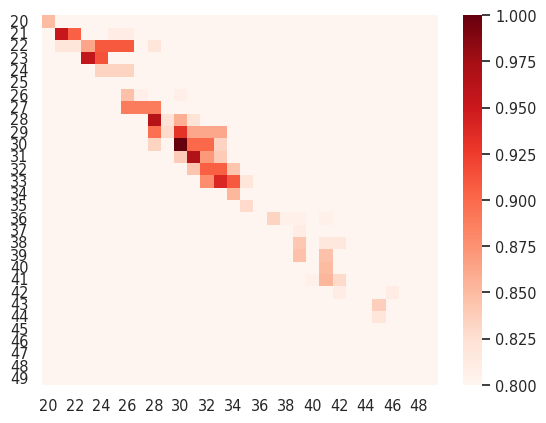

In [344]:
sns.heatmap(pd.Series(sim_samp).unstack(),cmap = 'Reds',yticklabels=True,vmin = 0.8)

<Axes: >

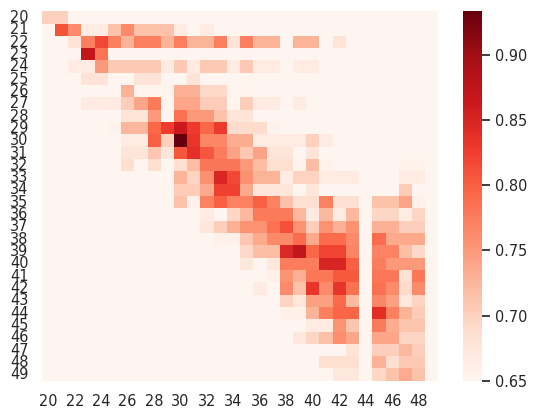

In [314]:
sns.heatmap(pd.Series(sim_samp).unstack(),cmap = 'Reds',yticklabels=True,vmin = 0.65)

<Axes: >

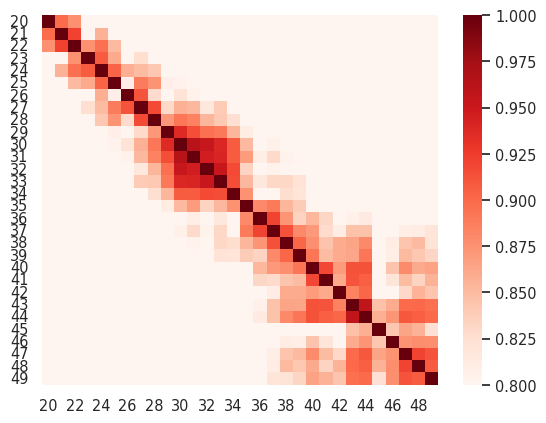

In [191]:
sns.heatmap(pd.Series(sim).unstack(),cmap = 'Reds',yticklabels=True,vmin = 0.8)

In [ ]:
final_B,final_A = outs[30]
z = znorm(final_B,axis = 0)


In [ ]:
# define loadings wrt pseudoinverse/projection matrix
gene_loadings = pd.DataFrame(((np.linalg.pinv(final_A))@pca.components_),columns = gene_names)
gene_loadings_A = pd.DataFrame((pca.components_.T@final_A).T,columns = gene_names)
Anload = znorm(gene_loadings_A,axis = 1)
Anload = Anload.loc[:,~Anload.columns.str.contains(r'LOC|MIR|MT|-NCRNA|RPL|^\d+')]
nload = znorm(gene_loadings,axis = 1)
nload = nload.loc[:,~nload.columns.str.contains(r'LOC|MIR|MT|-NCRNA|RPL|^\d+')]

In [ ]:
#perform gene set enrichment
import time
import gseapy as gp
libraries = [a for a in gp.get_library_name() if ('MSigDB_Hallmark' in a )or  ('Marker_2024' in a) or ('Process_2025' in a)]

def get_genes(nload, key,N = 50):
    a = nload.loc[key].sort_values()
    return a.index[:N],a.index[-N:]

In [ ]:



Agsea = {}
for i in range(30):
    time.sleep(2)
    for gl,ud in zip(get_genes(Anload,i,200), ['bot','top']):
        for lib in libraries:
            enr = gp.enrichr(gene_list=list(gl),
                            gene_sets=lib,
                            cutoff=1, # P-value cutoff for significance
                            no_plot=True) # Set to True to suppress plotting

            # print('\n'.join(p_bot))
            Agsea[lib,i,ud] = enr.results.copy()


gsea = {}
for i in range(30):
    time.sleep(2)
    for gl,ud in zip(get_genes(nload,i,200), ['bot','top']):
        for lib in libraries:
            enr = gp.enrichr(gene_list=list(gl),
                            gene_sets=lib,
                            cutoff=1, # P-value cutoff for significance
                            no_plot=True) # Set to True to suppress plotting

            # print('\n'.join(p_bot))
            gsea[lib,i,ud] = enr.results.copy()
            

            
bb = pd.concat(gsea)
Abb = pd.concat(Agsea)

In [ ]:
np.save('final_A', final_A)
final_B.to_pickle('final_B.pkl')
bb.to_pickle('bb.pkl')
Abb.to_pickle('Abb.pkl')



In [ ]:
#load in previous results
final_A = np.load('final_A.npy')
final_B = pd.read_pickle('final_B.pkl')
bb = pd.read_pickle('bb.pkl')
Abb = pd.read_pickle("Abb.pkl")

In [ ]:
# compute sample loadings with pseudoinv
samp_load = X_pc @ np.linalg.pinv(final_A).T
panc_sub = x_sub[label=='pancreatic adenocarcinoma']
pca2 = PCA(n_components = 30,random_state = 4)
within_panc_pc = pd.DataFrame(pca2.fit_transform(panc_sub),index=panc_sub.index)
overall_panc_pc =X_pc[label=='pancreatic adenocarcinoma'].iloc[:,:100]
mcpc_panc = samp_load.loc[panc_sub.index]

In [40]:
overall_thy_pc =X_pc[label=='thyroid carcinoma'].iloc[:,:100]
mcpc_thy = samp_load.loc[overall_thy_pc.index]


overall_lung_pc =X_pc[label=='lung adenocarcinoma'].iloc[:,:100]
mcpc_lung= samp_load.loc[overall_lung_pc.index]



Text(0.5, 0, '')

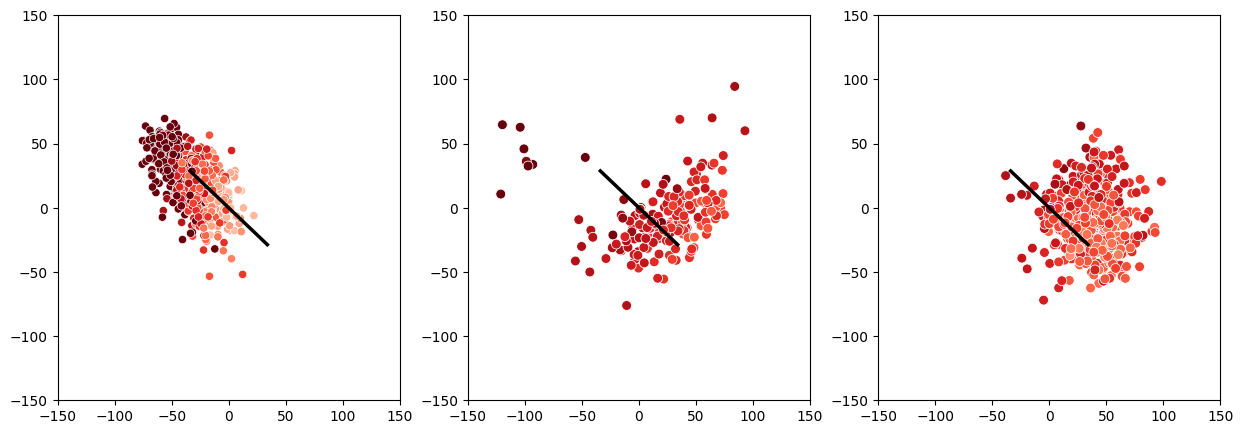

In [ ]:
plt.figure(figsize = (5,15))
plt.subplot(1,3,1)
sns.scatterplot(data = pd.concat([overall_thy_pc[[1,4,39]], mcpc_thy[24]],axis=1), x =1, y= 4, hue = 24,palette = 'Reds',hue_norm = (-100,20),legend = False)
plt.ylabel('')
plt.xlabel('')
plt.plot([100*i,-100*i], [100*j,-100*j],c= 'black',linewidth = 2.5)
plt.ylim(-150,150)
plt.xlim(-150,150)
plt.subplot(1,3,2)
plt.ylabel('')
plt.xlabel('')
sns.scatterplot(data = pd.concat([overall_panc_pc[[1,4,39]], mcpc_panc[24]],axis=1), x =1, y= 4, hue = 24,palette = 'Reds',legend = False,s = 50,hue_norm = (-100,20))
i,j = final_A[:,24][[1,39]]
plt.plot([100*i,-100*i], [100*j,-100*j],c= 'black',linewidth = 2.5)
plt.ylim(-150,150)
plt.xlim(-150,150)
plt.ylabel('')
plt.xlabel('')
plt.subplot(1,3,3)
sns.scatterplot(data = pd.concat([overall_lung_pc[[1,4,39]], mcpc_lung[24]],axis=1), x =1, y= 4, hue = 24,palette = 'Reds',legend = False,s = 50,hue_norm = (-100,20))
i,j = final_A[:,24][[1,39]]
plt.plot([100*i,-100*i], [100*j,-100*j],c= 'black',linewidth = 2.5)
plt
plt.ylim(-150,150)
plt.xlim(-150,150)
plt.ylabel('')
plt.xlabel('')

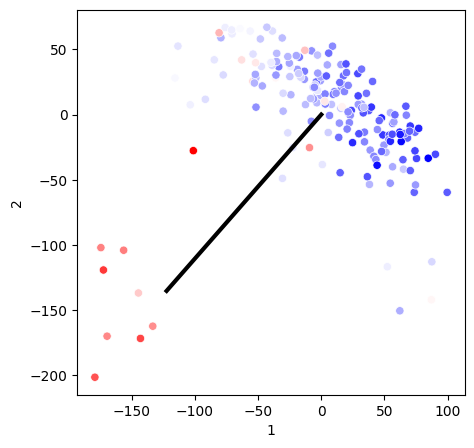

In [24]:
plt.figure(figsize = (5,5))
sns.scatterplot(data = pd.concat([within_panc_pc[[1,2]], mcpc_panc[24]],axis=1), x =1, y= 2, hue = 24,palette = 'bwr',legend = False)
plt.plot([0,-40*3.06], [0,-40*3.38],c= 'black',linewidth = 3)

<Axes: xlabel='variable', ylabel='value'>

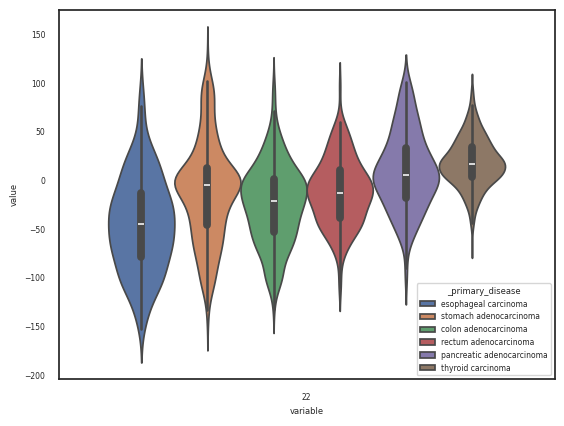

In [94]:
sub_lab = label[label.str.contains('colon|esophageal|stomach|rect|pancre|thyroid')]

df = pd.concat([samp_load.loc[sub_lab.index],sub_lab],axis=1)
mdf = df.melt(id_vars = '_primary_disease')
mdf = mdf[mdf['variable'].isin([22])]
mdf['variable'] = mdf['variable'].astype(str)
sns.set_style("white")
sns.violinplot(mdf, x = 'variable',y = 'value',hue = '_primary_disease',dodge=True,hue_order = ['esophageal carcinoma', 'stomach adenocarcinoma', 'colon adenocarcinoma', 'rectum adenocarcinoma', 'pancreatic adenocarcinoma','thyroid carcinoma'])

<Axes: xlabel='variable', ylabel='value'>

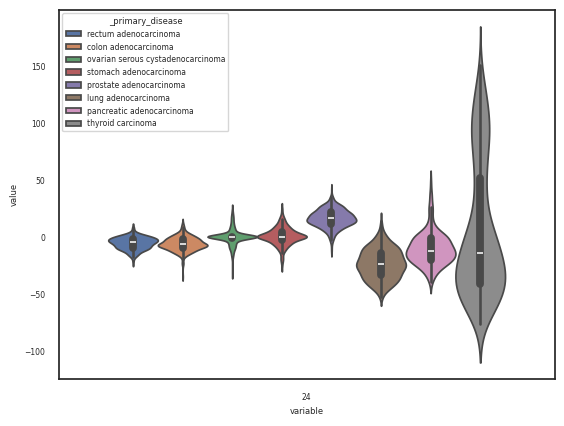

In [168]:
sub_lab = label[label.str.contains('adenoca|thyro')]
hue_order = df.groupby('_primary_disease')[24].std().sort_values().index.values
df = pd.concat([samp_load.loc[sub_lab.index],sub_lab],axis=1)
mdf = df.melt(id_vars = '_primary_disease')
mdf = mdf[mdf['variable'].isin([24])]
mdf['variable'] = mdf['variable'].astype(str)
sns.set_style("white")
sns.violinplot(mdf, x = 'variable',y = 'value',hue = '_primary_disease',dodge=True,hue_order = hue_order)
# sns.violinplot(mdf, x = 'variable',y = 'value',hue = '_primary_disease',dodge=True,hue_order = ['esophageal carcinoma', 'stomach adenocarcinoma', 'colon adenocarcinoma', 'rectum adenocarcinoma', 'pancreatic adenocarcinoma', 'thyroid carcinoma'])

In [169]:
from scipy.stats import spearmanr
spearmanr(mean_load[27], std_load[27]**2)

SignificanceResult(statistic=np.float64(-0.20978865406006672), pvalue=np.float64(0.2658489717443996))

In [8]:
from scipy.spatial.distance import cdist

/ewsc/sbhate/envs/CT/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)
/ewsc/sbhate/envs/CT/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)
/ewsc/sbhate/envs/CT/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


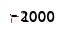

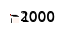

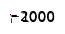

In [12]:
annots = pd.read_table('covid/tcga_annoations.txt').set_index('component')
a1 =annots[annots['specific'].isin([1])].index.values.copy()
a2 =annots[annots['specific'].isin([2])].index.values.copy()
a3 =annots[annots['specific'].isin([3])].index.values.copy()
dd = np.abs(1-cdist(final_B[a1].T, final_B[a1].T,metric='correlation'))
gg = sns.clustermap(dd,cmap  = 'Reds',vmax = 2500,metric = 'correlation',figsize = (0.1,0.1))
a1r = a1[gg.dendrogram_row.reordered_ind]

dd = np.abs(1-cdist(final_B[a2].T, final_B[a2].T,metric='correlation'))
gg = sns.clustermap(dd,cmap  = 'Reds',vmax = 2500,metric = 'correlation',figsize = (0.1,0.1))
a2r = a2[gg.dendrogram_row.reordered_ind]

dd = np.abs(1-cdist(final_B[a3].T, final_B[a3].T,metric='correlation'))
gg = sns.clustermap(dd,cmap  = 'Reds',vmax = 2500,metric = 'correlation',figsize = (0.1,0.1))
a3r = a3[gg.dendrogram_row.reordered_ind]


/ewsc/sbhate/envs/CT/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


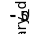

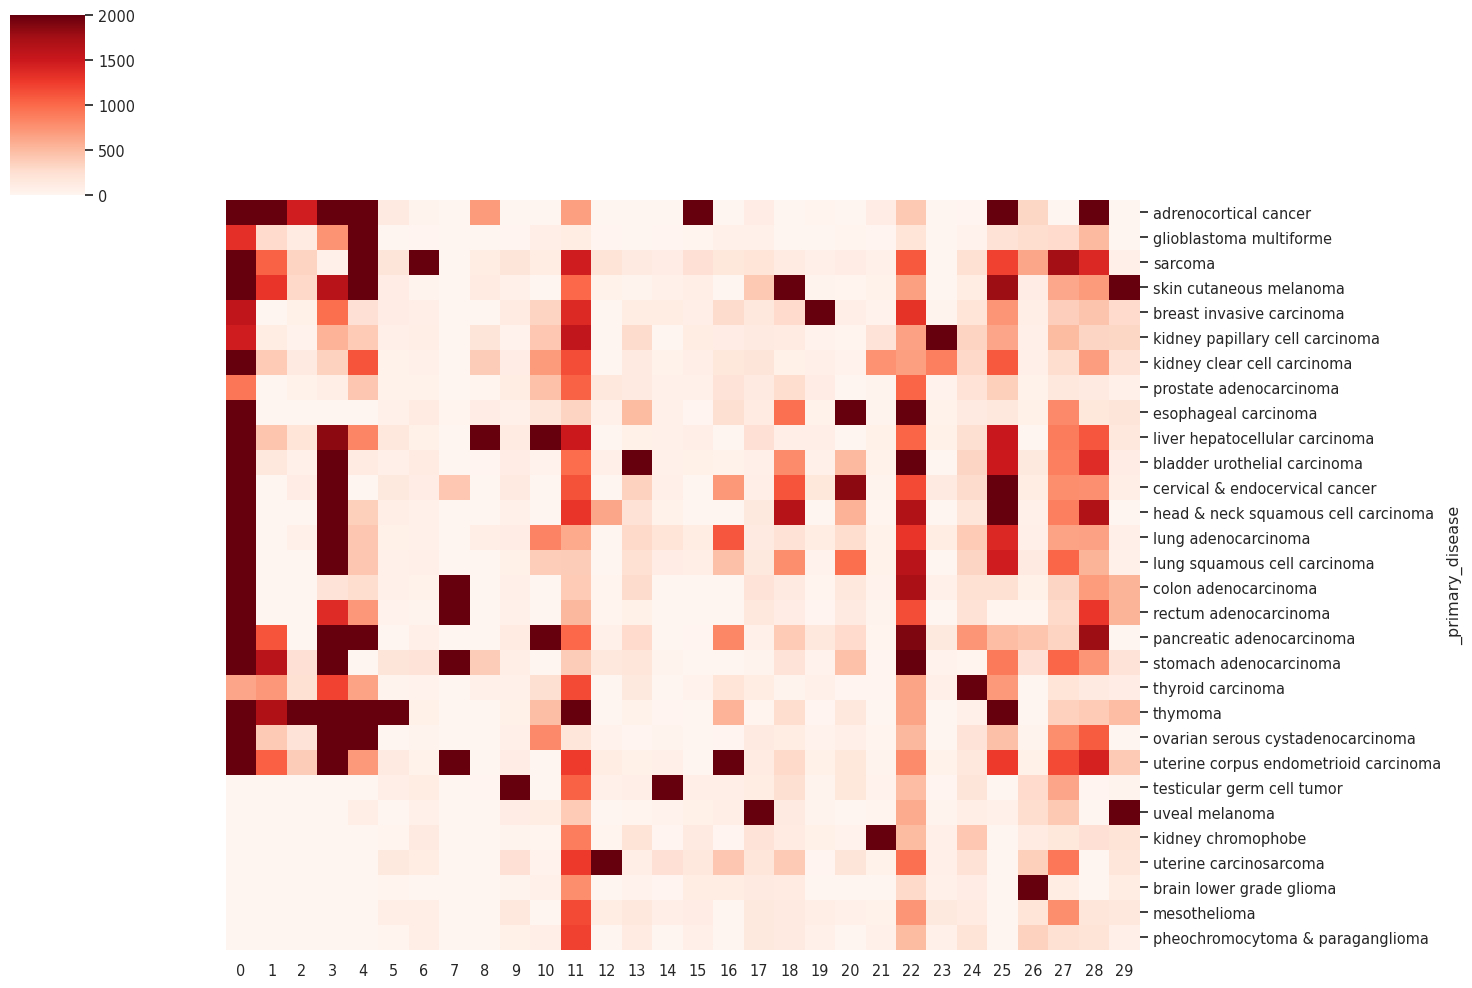

In [13]:
rr = sns.clustermap(znorm(final_B,axis=0),metric = 'correlation',figsize = (.01,.01))
new_ord = final_B.index[rr.dendrogram_row.reordered_ind]
sns.set(font_scale=0.95)

g = sns.clustermap(final_B,cmap = 'Reds', vmin = 0, vmax =2000,figsize =( 15,10),xticklabels=True,yticklabels = True,metric = 'correlation',col_cluster = False)
# g = sns.clustermap(final,cmap = 'bwr', vmin = -3, vmax =3,figsize =( 15,10),xticklabels=True,yticklabels = True,metric = 'correlation',col_cluster = False)
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)


In [17]:
md  = {j:i for i,j in enumerate(np.concatenate([a1r,a2r,a3r]))}

In [20]:
Abb['mcpc_ind'] = [md[a[1]] for a in Abb.index.values]

In [35]:
w = Abb.reset_index().set_index(['level_0','mcpc_ind', 'level_2','level_3']).sort_index()
w = w[w['Adjusted P-value']<0.001]
print(w.to_csv(sep = '\t'))


level_0	mcpc_ind	level_2	level_3	level_1	Gene_set	Term	Overlap	P-value	Adjusted P-value	Old P-value	Old Adjusted P-value	Odds Ratio	Combined Score	Genes
CellMarker_2024	0	bot	0	28	CellMarker_2024	Leydig Precursor Cell Fetal Gonad Human	44/221	8.678945604778251e-45	5.597919915081971e-42	0	0	31.269448066058235	3172.455272436029	SRPX;COL15A1;GLT8D2;THY1;PLOD1;NID1;FSTL1;LOXL2;MRC2;ISLR;EFEMP2;EDNRA;CALD1;SERPINH1;TIMP3;CPXM1;MSC;PDGFRB;POSTN;IGFBP4;TPM2;MMP2;CLEC11A;BGN;INHBA;SULF1;COL1A1;EHD2;COL3A1;COL5A1;CRISPLD2;COL6A2;PXDN;COL5A2;ITGA11;COL6A1;MFAP2;MXRA8;MYADM;CERCAM;SNAI2;VIM;ENG;FBN1
CellMarker_2024	0	bot	1	28	CellMarker_2024	Fibroblast Skin Mouse	31/90	7.026532979206669e-40	2.2660568857941512e-37	0	0	61.375087754488014	5533.1918817099	TAGLN;OLFML2B;LTBP2;THY1;THBS2;NID2;ISLR;CPXM1;IGFBP6;MSC;PDGFRB;PRRX1;LUM;MMP2;TPM2;GFPT2;IGF2;PCOLCE;SULF1;ACTA2;COL1A1;COL3A1;COL1A2;CRISPLD2;COL6A2;COL6A1;COL5A2;MXRA8;COL6A3;CD248;FBN1
CellMarker_2024	0	bot	2	28	CellMarker_2024	Fibrocartilage C

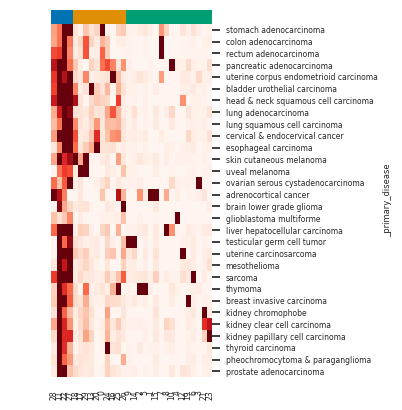

In [14]:
sns.set(font_scale = 0.5)
# k = final_B[np.concatenate([a1r,a2r,a3r])].T.rename(annots['name'].dropna().to_dict(), axis = 0)[new_ord]
k = final_B[np.concatenate([a1r,a2r,a3r])].T[new_ord]
pal = sns.color_palette('colorblind',3)
colors = [pal[0]]*len(a1r) +  [pal[1]]*len(a2r) + [pal[2]]*len(a3r)
gg = sns.clustermap((k/k.values.max(axis = 1,keepdims=True)).T, row_cluster = False,vmax = 0.4,  cmap = 'Reds',metric = 'euclidean',figsize = (4,5),yticklabels=True,xticklabels=True, col_cluster = False, col_colors = colors)
gg.ax_col_dendrogram.set_visible(False)
gg.ax_cbar.set_visible(False)

In [38]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sklearn.model_selection import KFold

In [17]:
surv = pd.read_table('/data/sbhate/mcpc/spm-private/downstream/Survival_SupplementalTable_S1_20171025_xena_sp').set_index('sample')
# surv = surv[surv['_PATIENT'].isin(mean_pcs.index)][['_PATIENT','OS','OS.time','DSS','DSS.time','cancer type abbreviation']].drop_duplicates().set_index("_PATIENT")


In [18]:
y = pd.concat([surv,samp_load])[['OS','OS.time']].dropna()

In [ ]:
from lifelines import CoxPHFitter
y = pd.concat([surv,samp_load],axis=1)
# dat = y[(y['cancer type abbreviation']=='PAAD') & (~y['OS'].isna())]
dat = y[(y['cancer type abbreviation']=='PAAD') & (~y['OS'].isna()) & (~y['OS.time'].isna()) & (~y[24].isna())]
cph = CoxPHFitter()
cph.fit(dat[['OS.time','OS',24]].dropna(), duration_col='OS.time', event_col='OS')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 501 total observations, 494 right-censored observations>
             duration col = 'DSS.time'
                event col = 'DSS'
      baseline estimation = breslow
   number of observations = 501
number of events observed = 7
   partial log-likelihood = -38.07
         time fit was run = 2025-12-06 00:23:45 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
24         0.01      1.01      0.01           -0.01            0.02                0.99                1.02

           cmp to    z    p  -log2(p)
covariate                            
24           0.00 1.11 0.27      1.90
---
Concordance = 0.51
Partial AIC = 78.14
log-likelihood ratio test = 1.15 on 1 df
-log2(p) of ll-ratio test = 1.82

In [19]:
from lifelines import CoxPHFitter
y = pd.concat([surv,samp_load],axis=1)
# dat = y[(y['cancer type abbreviation']=='PAAD') & (~y['OS'].isna())]
dat = y[(y['cancer type abbreviation']=='PAAD') & (~y['OS'].isna()) & (~y['OS.time'].isna()) & (~y[24].isna())]
cph = CoxPHFitter()
cph.fit(dat[['OS.time','OS',24]].dropna(), duration_col='OS.time', event_col='OS')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 185 total observations, 85 right-censored observations>
             duration col = 'OS.time'
                event col = 'OS'
      baseline estimation = breslow
   number of observations = 185
number of events observed = 100
   partial log-likelihood = -439.63
         time fit was run = 2025-12-05 23:56:44 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
24        -0.03      0.97      0.01           -0.04           -0.01                0.96                0.99

           cmp to     z      p  -log2(p)
covariate                               
24           0.00 -3.40 <0.005     10.54
---
Concordance = 0.57
Partial AIC = 881.25
log-likelihood ratio test = 13.01 on 1 df
-log2(p) of ll-ratio test = 11.66

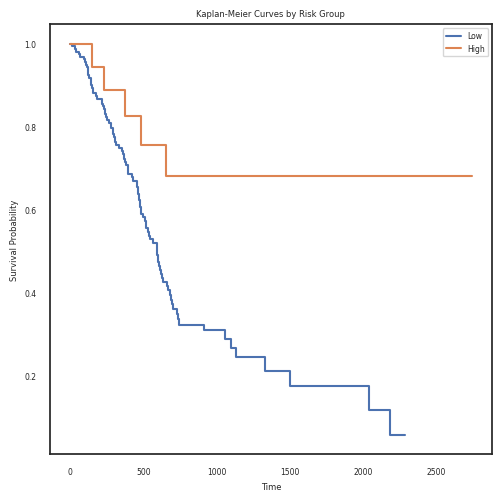

In [ ]:

from lifelines import KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming you have: df with 'time', 'event', and 'continuous_var'

# Create strata (tertiles, quartiles, or custom bins)
dat = y[(y['cancer type abbreviation']=='PAAD') & (~y['OS'].isna()) & (~y['OS.time'].isna()) & (~y[24].isna())]
df = dat.copy()
# df['strata'] = pd.qcut(df[24], q=2, labels=['Low','High'])
# Or for quartiles: q=4
# Or custom bins: pd.cut(df['continuous_var'], bins=[0, 10, 20, 30], labels=[...])
df['strata'] = pd.cut(df[24],bins = [-1e5, np.percentile(df[24],90),1e5], labels=['Low','High'])
# Fit KM for each stratum
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(5, 5))

for stratum in df['strata'].unique():
    mask = df['strata'] == stratum
    kmf.fit(df.loc[mask, 'OS.time'], 
            df.loc[mask, 'OS'], 
            label=f'{stratum}')
    kmf.plot_survival_function(ax=ax, ci_show=False)

plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.title('Kaplan-Meier Curves by Risk Group')
plt.legend()

# Optional: add at-risk counts below the plot
# add_at_risk_counts(kmf, ax=ax)

plt.tight_layout()
plt.show()

In [144]:
from lifelines.statistics import multivariate_logrank_test

results = multivariate_logrank_test(df['OS.time'], df['strata'], df['OS'])
print(f"Log-rank p-value: {results.p_value:.4f}")

Log-rank p-value: 0.0039
